<a href="https://colab.research.google.com/github/KRISHNA-EP18/Machine_Learning_IMLE/blob/main/nasa_battery_interpolation_svd_regression_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NASA Li-Ion Battery Data → Interpolation → SVD → Regression

This tutorial builds a complete machine-learning pipeline for predicting battery capacity from voltage-discharge curves in the NASA Li-ion battery dataset.

We will:

1. Load the NASA battery data from Google Drive.
2. Extract voltage curves and capacity.
3. Perform a chronological train/test split.
4. Build reusable interpolation/preprocessing functions.
5. Determine a suitable interpolation dimension using training data.
6. Compare interpolation methods.
7. Create the final uniform training matrix.
8. Apply SVD.
9. Select the number of principal axes using explained variance.
10. Project the training data and train Linear Regression.
11. Apply the same learned transformations to the test data.
12. Calculate MAE, RMSE, and R².
13. Compare alternative regression models.

**Important principle:** anything that learns information from the data is learned from the training set only. The test set is reserved for final evaluation.

## Module 1 — Setup and Load the NASA Data

We first import NumPy for numerical operations, Matplotlib for visualization, SciPy for reading the MATLAB file and interpolation, and Scikit-learn for regression and evaluation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.interpolate import interp1d

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.svm import SVR

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


### Loading the MATLAB file

The NASA battery dataset is provided as MATLAB `.mat` files. After mounting Google Drive, specify the folder containing the battery file and load it with `loadmat()`.

In [ ]:
from pathlib import Path

data_folder = Path("/content/drive/MyDrive")

print("Data folder:")
print(data_folder)


try:
  mat_file = list(data_folder.rglob('B0005.mat'))[0]

  print("MAT file:")
  print(mat_file)

  print("Does the file exist?")
  print(mat_file.exists())

except FileNotFoundError:
  print("No file found.")
except IndexError:
  print("Filepath Not existing")

data = loadmat(mat_file)

print(data.keys())

Data folder:
/content/drive/MyDrive
MAT file:
/content/drive/MyDrive/BML_SVD/5. Battery Data Set/1. BatteryAgingARC-FY08Q4/B0005.mat
Does the file exist?
True
dict_keys(['__header__', '__version__', '__globals__', 'B0005'])


## Module 2 — Extract the NASA Battery Data

The NASA data is stored in a nested MATLAB structure. Each battery contains multiple cycles, and each cycle contains measurements such as `Voltage_measured` and `Capacity`.

We create a function so that the extraction logic is reusable. The voltage curves are retained as a list because different cycles can contain different numbers of measurements.

In [ ]:
def extract_battery_data(B):

    cycles = B["cycle"].ravel()

    # Get cycle types
    cycle_types = np.array([
        str(c["type"].ravel()[0])
        for c in cycles
    ])

    # Create discharge mask
    discharge_mask = np.where(
        cycle_types == "discharge"
    )[0]

    # Apply mask
    discharge_cycles = cycles[discharge_mask]

    voltage_curves = []
    capacities = []

    for cycle in discharge_cycles:

        data = cycle["data"].ravel()[0]

        voltage = np.asarray(
            data["Voltage_measured"]
        ).ravel()

        cap = np.asarray(
            data["Capacity"]
        ).ravel()

        voltage_curves.append(voltage)
        capacities.append(cap[0])

    return voltage_curves, np.asarray(capacities)

### Extract and inspect the data

We now extract battery B0005 and inspect the first few cycles. The varying number of voltage measurements is the reason we need interpolation before constructing a matrix for SVD and machine learning.

In [ ]:
B0005 = data["B0005"].ravel()[0]

voltage_curves, capacity = extract_battery_data(B0005)

print("Number of discharge cycles:", len(voltage_curves))
print("Capacity shape:", capacity.shape)

for i in range(min(5, len(voltage_curves))):

    print(
        f"Cycle {i+1}: "
        f"{len(voltage_curves[i])} voltage points, "
        f"Capacity = {capacity[i]:.4f}"
    )

Number of discharge cycles: 168
Capacity shape: (168,)
Cycle 1: 197 voltage points, Capacity = 1.8565
Cycle 2: 196 voltage points, Capacity = 1.8463
Cycle 3: 195 voltage points, Capacity = 1.8353
Cycle 4: 194 voltage points, Capacity = 1.8353
Cycle 5: 194 voltage points, Capacity = 1.8346


If different cycles contain different numbers of voltage measurements, they cannot directly form a rectangular matrix.

For example:

```text
Cycle 1 → 197 points
Cycle 2 → 203 points
Cycle 3 → 211 points
```

Machine-learning algorithms generally require every sample to have the same number of features. We therefore represent every voltage curve using a common number of uniformly positioned points.

## Module 3 — Train/Test Split

For battery degradation, a chronological split is appropriate. Earlier cycles are used for training and later cycles are used for testing.

This resembles the real prediction problem: use previously observed degradation to predict future degradation.

We deliberately do not randomly shuffle the cycles.

In [ ]:
n = len(voltage_curves)

split = int(0.8 * n)

X_raw_train = voltage_curves[:split]
X_raw_test = voltage_curves[split:]

y_train = capacity[:split]
y_test = capacity[split:]

print("Training samples:", len(X_raw_train))
print("Testing samples :", len(X_raw_test))

Training samples: 134
Testing samples : 34


From this point onward, the training set is the only dataset used to determine parameters such as interpolation dimension, interpolation method, the mean curve, SVD basis, number of principal axes, and regression coefficients.

The test set is used only after these choices have been fixed.

## Module 4 — Reusable Preprocessing Functions

We will experiment with interpolation dimensions and interpolation methods. Instead of rewriting preprocessing code for every experiment, we create reusable functions.

`interpolate_curve()` handles one voltage curve.

`preprocess_voltage_curves()` applies the interpolation to a collection of curves.

The main parameters are:

- `voltage_curves`
- `dimension`
- `interpolation`

This allows us to repeatedly call the same function with different experimental settings.

In [ ]:
def interpolate_curve(
    voltage,
    dimension,
    interpolation="linear"
):

    voltage = np.asarray(
        voltage
    ).ravel()

    old_x = np.linspace(
        0,
        1,
        len(voltage)
    )

    new_x = np.linspace(
        0,
        1,
        dimension
    )

    interpolator = interp1d(
        old_x,
        voltage,
        kind=interpolation
    )

    return interpolator(new_x)


def preprocess_voltage_curves(
    voltage_curves,
    dimension,
    interpolation="linear"
):

    X = np.array([
        interpolate_curve(
            voltage,
            dimension,
            interpolation
        )
        for voltage in voltage_curves
    ])

    return X

### What does interpolation do?

The original voltage measurements are associated with their positions along the curve. We normalize these positions to the interval

\[
0 \leq x \leq 1.
\]

If a curve originally has 197 measurements and we choose a new dimension of 200, interpolation estimates the voltage at 200 uniformly distributed positions.

We are therefore constructing a new uniformly sampled representation of the same curve, rather than simply appending new values to the original array.

## Module 5 — Determine the Best Interpolation Dimension

We need enough points to preserve the important shape of the voltage curve, but using unnecessarily many points increases the dimensionality of the problem.

We test several candidate dimensions.

For each dimension we:

1. Interpolate each training curve.
2. Reconstruct it at its original measurement positions.
3. Calculate reconstruction RMSE.
4. Average the error across the training curves.

The test set is not involved in this experiment.

In [ ]:
def select_interpolation_dimension(
    candidate_dimensions,
    X_raw_train,
    threshold=0.005,
    consecutive=2
):

    dimension_error = []

    for dimension in candidate_dimensions:

        errors = []

        for voltage in X_raw_train:

            voltage_interp = interpolate_curve(
                voltage,
                dimension,
                interpolation="linear"
            )

            original_x = np.linspace(
                0,
                1,
                len(voltage)
            )

            interp_x = np.linspace(
                0,
                1,
                dimension
            )

            interpolator = interp1d(
                interp_x,
                voltage_interp,
                kind="linear"
            )

            reconstructed = interpolator(
                original_x
            )

            error = np.sqrt(
                np.mean(
                    (voltage - reconstructed) ** 2
                )
            )

            errors.append(error)

        dimension_error.append(
            np.mean(errors)
        )


    # Calculate relative improvement
    improvements = []

    for i in range(1, len(dimension_error)):

        improvement = (
            dimension_error[i - 1]
            - dimension_error[i]
        ) / dimension_error[i - 1]

        improvements.append(improvement)


    # Find convergence point
    best_dimension = candidate_dimensions[-1]

    for i in range(
        consecutive - 1,
        len(improvements)
    ):

        recent_improvements = improvements[
            i - consecutive + 1 : i + 1
        ]

        if all(
            improvement < threshold
            for improvement in recent_improvements
        ):

            best_dimension = candidate_dimensions[
                i + 1
            ]

            break


    return best_dimension, dimension_error

In [ ]:
candidate_dimensions = [50,100,150,200]
best_dimension, dimension_error = (
    select_interpolation_dimension(
        candidate_dimensions,
        X_raw_train,
        threshold=0.05,
        consecutive=2
    )
)

In [ ]:
best_dimension

200

### Visualizing the dimension experiment

A lower reconstruction RMSE means that the interpolated representation is closer to the original measurements.

We select the candidate dimension with the lowest average reconstruction error.

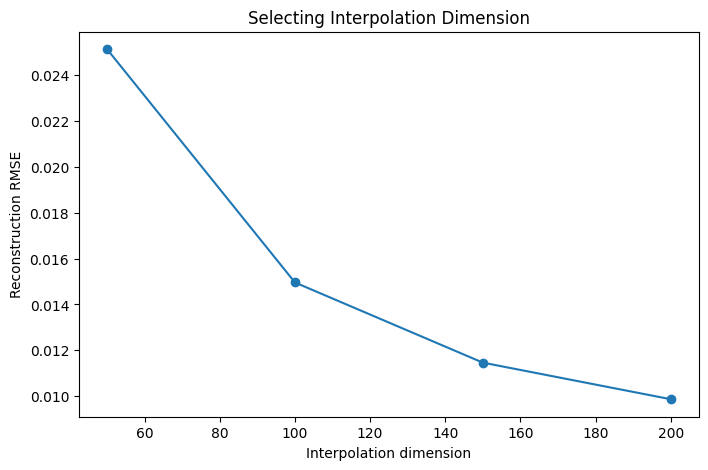

Best interpolation dimension: 200


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    candidate_dimensions,
    dimension_error,
    marker="o"
)

plt.xlabel("Interpolation dimension")
plt.ylabel("Reconstruction RMSE")
plt.title("Selecting Interpolation Dimension")

plt.show()

#best_dimension = candidate_dimensions[   np.argmin(dimension_error)]

print(
    "Best interpolation dimension:",
    best_dimension
)

## Module 6 — Determine the Interpolation Method

The interpolation dimension and interpolation method are separate choices.

We compare nearest-neighbour, linear, and cubic interpolation while keeping the selected dimension fixed.

The same reconstruction-error criterion is used. For this battery dataset, linear interpolation is also a useful baseline because higher-order interpolation can introduce artificial oscillations around sharp changes in a curve.

In [ ]:
interpolation_methods = [
    "linear",
    "nearest",
    "cubic"
]

interpolation_errors = {}

best_dimension = best_dimension

for method in interpolation_methods:

    errors = []

    for voltage in X_raw_train:

        voltage_interp = interpolate_curve(
            voltage,
            best_dimension,
            interpolation=method
        )

        original_x = np.linspace(
            0,
            1,
            len(voltage)
        )

        interp_x = np.linspace(
            0,
            1,
            best_dimension
        )

        interpolator = interp1d(
            interp_x,
            voltage_interp,
            kind=method
        )

        reconstructed = interpolator(
            original_x
        )

        error = np.sqrt(
            np.mean(
                (voltage - reconstructed) ** 2
            )
        )

        errors.append(error)

    interpolation_errors[method] = np.mean(
        errors
    )

for method, error in interpolation_errors.items():

    print(
        f"{method}: {error:.6f}"
    )

best_interpolation = min(
    interpolation_errors,
    key=interpolation_errors.get
)

print(
    "\nBest interpolation:",
    best_interpolation
)

linear: 0.009869
nearest: 0.013359
cubic: 0.008382

Best interpolation: cubic


At this point we have experimentally determined the two preprocessing parameters:

```python
best_dimension
best_interpolation
```

These values are now fixed and will be used for both training and test data.

## Module 7 — Final Training Preprocessing

We now perform the final preprocessing of the training data using the selected dimension and interpolation method.

If there are \(N\) training cycles and the selected interpolation dimension is \(D\), the resulting matrix has shape

\[
X_{train} \in \mathbb{R}^{N \times D}.
\]

In [ ]:
X_train = preprocess_voltage_curves(
    X_raw_train,
    dimension=best_dimension,
    interpolation=best_interpolation
)

print(
    "Training matrix shape:",
    X_train.shape
)

Training matrix shape: (134, 200)


### Centering the training matrix

Before applying SVD, we center every feature by subtracting its training-set mean:

\[
X_c = X - \bar{X}.
\]

The mean is calculated only from the training data. The same mean will later be used to center the test data.

In [ ]:
X_mean = np.mean(
    X_train,
    axis=0
)

X_train_centered = (
    X_train - X_mean
)

print(
    "Centered training shape:",
    X_train_centered.shape
)

Centered training shape: (134, 200)


## Module 8 — SVD and Principal Axis Selection

We now decompose the centered training matrix using Singular Value Decomposition:

\[
X_c = U\Sigma V^T.
\]

Here:

- \(U\) contains the left singular vectors.
- \(\Sigma\) contains the singular values.
- \(V^T\) contains the right singular vectors.

The rows of \(V^T\) represent directions in the original voltage-feature space. The singular values indicate how much variation is associated with those directions.

In [ ]:
U, S, Vt = np.linalg.svd(
    X_train_centered,
    full_matrices=False
)

print("U shape :", U.shape)
print("S shape :", S.shape)
print("Vt shape:", Vt.shape)

U shape : (134, 134)
S shape : (134,)
Vt shape: (134, 200)


### Selecting the number of principal axes

We do not necessarily need every SVD component.

The squared singular values are proportional to the variance captured by the corresponding principal directions:

\[
\text{Variance}_i \propto S_i^2.
\]

We calculate the explained-variance ratio and cumulative explained variance. Here we use 95% cumulative explained variance as the selection criterion.

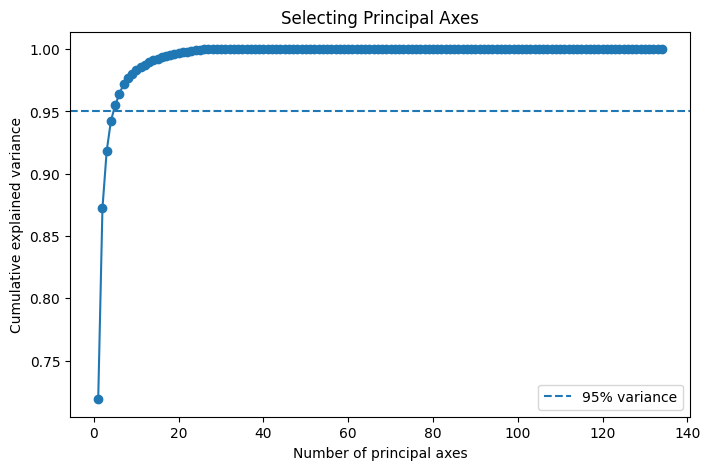

Selected principal axes: 5


In [ ]:
explained_variance = S**2

explained_variance_ratio = (
    explained_variance /
    np.sum(explained_variance)
)

cumulative_variance = np.cumsum(
    explained_variance_ratio
)

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(S) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    0.95,
    linestyle="--",
    label="95% variance"
)

plt.xlabel("Number of principal axes")
plt.ylabel("Cumulative explained variance")
plt.title("Selecting Principal Axes")

plt.legend()
plt.show()

variance_threshold = 0.95

n_components = (
    np.argmax(
        cumulative_variance >= variance_threshold
    ) + 1
)

print(
    "Selected principal axes:",
    n_components
)

## Module 9 — Project Training Data and Train Linear Regression

We retain the selected principal axes and project the centered training data into this lower-dimensional SVD space:

\[
Z = X_cV_k.
\]

The original feature space has \(D\) dimensions, while the reduced space has \(k\) dimensions.

In [ ]:
V_selected = Vt[
    :n_components
].T

Z_train = (
    X_train_centered @ V_selected
)

print(
    "Original training shape:",
    X_train.shape
)

print(
    "Reduced training shape:",
    Z_train.shape
)

Original training shape: (134, 200)
Reduced training shape: (134, 5)


### Training Linear Regression

The reduced SVD coordinates become the input features for Linear Regression.

The model learns:

\[
\hat Q =
\beta_0+
\beta_1z_1+
\beta_2z_2+
\cdots+
\beta_kz_k,
\]

where \(Q\) is battery capacity and \(z_1,\ldots,z_k\) are the selected SVD coordinates.

In [ ]:
model = LinearRegression()

model.fit(
    Z_train,
    y_train
)

LinearRegression()

## Module 10 — Process the Test Data

The test data must undergo exactly the same transformation learned from the training data.

We use:

- the same interpolation dimension,
- the same interpolation method,
- the training mean,
- the training SVD basis.

We do **not** calculate a new mean or a new SVD for the test data.

The transformation is

\[
X_{test}
\rightarrow
X_{test}-\bar X_{train}
\rightarrow
V_k
\rightarrow
Z_{test}.
\]

In [ ]:
X_test = preprocess_voltage_curves(
    X_raw_test,
    dimension=best_dimension,
    interpolation=best_interpolation
)

print(
    "Test matrix shape:",
    X_test.shape
)

# Center using the TRAINING mean
X_test_centered = (
    X_test - X_mean
)

# Project using the TRAINING SVD basis
Z_test = (
    X_test_centered @ V_selected
)

print(
    "Reduced test shape:",
    Z_test.shape
)

Test matrix shape: (34, 200)
Reduced test shape: (34, 5)


## Module 11 — Prediction and Evaluation

The test data is now represented in the same reduced feature space as the training data.

We use three common regression metrics:

### MAE

\[
MAE = \frac{1}{N}\sum |y_i-\hat y_i|
\]

MAE is the average absolute prediction error.

### RMSE

\[
RMSE =
\sqrt{
\frac{1}{N}\sum(y_i-\hat y_i)^2
}
\]

RMSE penalizes larger errors more strongly.

### R²

\[
R^2 =
1-
\frac{\sum(y_i-\hat y_i)^2}
{\sum(y_i-\bar y)^2}
\]

An \(R^2\) closer to 1 indicates that the model explains more of the variation in the target.

In [ ]:
y_pred = model.predict(
    Z_test
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("RESULTS")
print("-------")

print(
    "Interpolation dimension:",
    best_dimension
)

print(
    "Interpolation method:",
    best_interpolation
)

print(
    "Principal axes:",
    n_components
)

print(
    "MAE :", mae
)

print(
    "RMSE:", rmse
)

print(
    "R²  :", r2
)

RESULTS
-------
Interpolation dimension: 200
Interpolation method: cubic
Principal axes: 5
MAE : 0.017586775681655363
RMSE: 0.02177047597542826
R²  : 0.03932518269350538


### Visualizing the prediction

We compare the actual capacity values with the values predicted by the Linear Regression model.

A good model should reproduce the overall battery degradation trend.

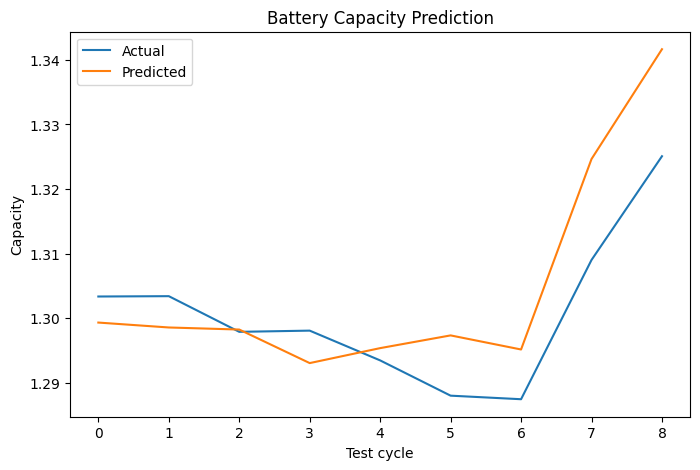

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    y_test,
    label="Actual"
)

plt.plot(
    y_pred,
    label="Predicted"
)

plt.xlabel("Test cycle")
plt.ylabel("Capacity")
plt.title("Battery Capacity Prediction")

plt.legend()
plt.show()

## Module 12 — Compare Alternative Regression Models

Linear Regression assumes that the relationship between the SVD features and capacity is approximately linear.

Battery degradation can contain nonlinear behaviour, so we can compare alternative regression models.

The preprocessing and SVD stages remain unchanged. Every model receives exactly the same `Z_train` and `Z_test`.

Models included:

- **Linear Regression** — linear baseline.
- **Ridge** — linear regression with L2 regularization.
- **Lasso** — linear regression with L1 regularization.
- **Elastic Net** — combination of L1 and L2 regularization.
- **SVR** — nonlinear support-vector regression using an RBF kernel.
- **Random Forest** — nonlinear tree-based ensemble.
- **Gradient Boosting** — sequential tree-based ensemble.

In [ ]:
models = {

    "Linear Regression":
        LinearRegression(),

    "Ridge":
        Ridge(alpha=1.0),

    "Lasso":
        Lasso(alpha=0.001),

    "Elastic Net":
        ElasticNet(
            alpha=0.001,
            l1_ratio=0.5
        ),

    "SVR":
        SVR(
            kernel="rbf",
            C=100
        ),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=300,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            n_estimators=200,
            random_state=42
        )
}

results = {}

for name, model in models.items():

    model.fit(
        Z_train,
        y_train
    )

    prediction = model.predict(
        Z_test
    )

    results[name] = {

        "MAE":
            mean_absolute_error(
                y_test,
                prediction
            ),

        "RMSE":
            np.sqrt(
                mean_squared_error(
                    y_test,
                    prediction
                )
            ),

        "R2":
            r2_score(
                y_test,
                prediction
            )
    }

print(
    f"{'Model':<22}"
    f"{'MAE':>12}"
    f"{'RMSE':>12}"
    f"{'R²':>12}"
)

print("-" * 58)

for name, metrics in results.items():

    print(
        f"{name:<22}"
        f"{metrics['MAE']:>12.4f}"
        f"{metrics['RMSE']:>12.4f}"
        f"{metrics['R2']:>12.4f}"
    )

Model                          MAE        RMSE          R²
----------------------------------------------------------
Linear Regression           0.0178      0.0219      0.0271
Ridge                       0.0233      0.0279     -0.5799
Lasso                       0.0316      0.0359     -1.6054
Elastic Net                 0.0245      0.0291     -0.7124
SVR                         0.1452      0.1474    -43.0665
Random Forest               0.0428      0.0480     -3.6723
Gradient Boosting           0.0373      0.0422     -2.6108


# Final Conceptual Pipeline

The complete workflow implemented in this notebook is:

```text
NASA .mat file
      ↓
Extract voltage curves + capacity
      ↓
Chronological train/test split
      ↓
TRAINING DATA
      ↓
Find interpolation dimension
      ↓
Find interpolation method
      ↓
Final interpolation
      ↓
Center using training mean
      ↓
SVD
      ↓
Select principal axes
      ↓
Project → Z_train
      ↓
Train regression
      │
      └──────────────────────────────┐
                                     │
TEST DATA                            │
      ↓                              │
Same dimension                       │
Same interpolation                   │
      ↓                              │
Center using TRAIN mean              │
      ↓                              │
Project using TRAIN V                │
      ↓                              │
Z_test                               │
      ↓                              │
Prediction                           │
      ↓                              │
MAE / RMSE / R²                      │
                                     │
Alternative regression models ◄──────┘
```

The key methodological rule is that the test set never participates in selecting preprocessing or dimensionality-reduction parameters. It is only transformed using information learned from the training set and then used for final evaluation.